In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

In [4]:
file_path= "/content/drive/My Drive/en.openfoodfacts.org.products.csv.gz"

In [ ]:
df_peak = pd.read_csv(file_path, sep='\t',nrows=5)

for col in df_peak.columns:
    print(col)

code
url
creator
created_t
created_datetime
last_modified_t
last_modified_datetime
last_modified_by
last_updated_t
last_updated_datetime
product_name
abbreviated_product_name
generic_name
quantity
packaging
packaging_tags
packaging_en
packaging_text
brands
brands_tags
brands_en
categories
categories_tags
categories_en
origins
origins_tags
origins_en
manufacturing_places
manufacturing_places_tags
labels
labels_tags
labels_en
emb_codes
emb_codes_tags
first_packaging_code_geo
cities
cities_tags
purchase_places
stores
countries
countries_tags
countries_en
ingredients_text
ingredients_tags
ingredients_analysis_tags
allergens
allergens_en
traces
traces_tags
traces_en
serving_size
serving_quantity
no_nutrition_data
additives_n
additives
additives_tags
additives_en
nutriscore_score
nutriscore_grade
nova_group
pnns_groups_1
pnns_groups_2
food_groups
food_groups_tags
food_groups_en
states
states_tags
states_en
brand_owner
environmental_score_score
environmental_score_grade
nutrient_levels_tags
p

In [109]:
use_cols=[
    'code','brands','countries_tags', 'main_category',
    'nutriscore_grade', 'nova_group', 'environmental_score_score',
    'additives_n',
    'energy-kcal_100g', 'energy-kj_100g','fat_100g', 'saturated-fat_100g', 'sugars_100g',
    'proteins_100g', 'salt_100g', 'fiber_100g', 'sodium_100g'
]
df = pd.read_csv(file_path, sep='\t', usecols=use_cols)
df.head()

/tmp/ipython-input-76281890.py:8: DtypeWarning:

Columns (0,53,59,69,88,92,93) have mixed types. Specify dtype option on import or set low_memory=False.



,code,brands,countries_tags,additives_n,nutriscore_grade,nova_group,environmental_score_score,main_category,energy-kj_100g,energy-kcal_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
0,2,NaN,en:germany,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,NaN,en:france,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,NaN,en:france,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,NaN,en:france,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6,NaN,en:germany,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Metrik Açıklamaları (=Feature Description)**
Veri setinin projede kullanılan kısımlarının açıklaması.

- code = sıra numarası ID
- product_name = ürün adı
- brands = hangi markanın ürünü
- main_category = ürünün ana kategorisi
- countries_tags = ürün hangi ülkede satılıyor
- additives_n = ürünün içeriğindeki katkı maddesi sayısı
- nutriscore_grade = ürünlerin a-e arasında aldığı değer ürünün ne kadar besin kalitesinin yüksek olduğunu gösteriyor (işlenmişlik derecesi burada dikkate alınmaz 100g üzerinden belirlenir)
  - a = en yüksek
  - b = iyi kalite
  - c = orta kalite
  - d = düşük kalite
  - e = en düşük besin kalitesi anlamına geliyor
- nova_group = ürünün ne kadar doğal (az işlenmiş) olduğunu gösterir
  - 1 = işlenmemiş veya az işlenmiş
  - 2 = işlenmiş
  - 3 = iyi işlenmiş
  - 4 = aşırı işlenmiş gıdalar anlamına gelmektedir.
- enviromental_score_score = ürünün üretiminden paketlenmesine ve nakliyesine kadar geçen süreçteki ekolojik ayak izini temsil eder. 0-100 arası değer alır. Değerin yüksek olması çevre için daha iyi olduğu anlamına gelir.
- energy-kcal_100g = ürünün 100 gramının sindirimi sonucu açığa çıkan, yaygın olarak kullanılan enerji birimidir.
- energy-kj_100g = ürünün 100 gramlık miktarının vücuda sağladığı toplam termokimyasal enerjiyi ifade eder.
- fat_100g = ürünün 100 gramında ne kadar yağ içerdiğini açıklıyor
- saturated-fat_100g = ürünün 100 gramında kaç gram doymuş yağ içerdiğini açıklıyor
- sugars_100g = ürünün 100 gramında kaç gram şeker içerdiğini açıklıyor
- fiber_100g = ürünün 100 gramında kaç gram lif içerdiğini açıklıyor
- proteins_100g = ürünün 100 gramında kaç gram protein içerdiğini açıklıyor
- salt_100g = ürünün 100 gramında kaç gram tuz içerdiğini açıklıyor
- sodium_100g = ürünün 100 gramında kaç gram sodyum minerali içerdiğini açıklıyor

In [110]:
df.shape

(4314543, 17)

In [111]:
missing_ratios = df.isnull().mean() * 100
missing_ratios = missing_ratios.sort_values(ascending=False)
missing_ratios

,0
energy-kj_100g,90.444898
environmental_score_score,81.268514
nova_group,74.495792
additives_n,71.086949
fiber_100g,64.174352
main_category,58.092479
brands,37.756397
sodium_100g,37.263808
salt_100g,37.263784
saturated-fat_100g,32.947522


In [120]:
df_clean = df.dropna(subset=[
    'nutriscore_grade',
    'nova_group',
    'environmental_score_score',
    'saturated-fat_100g',
    'energy-kj_100g',
    "salt_100g",
    "sugars_100g",
    "proteins_100g",
    "fat_100g",
    "additives_n"
])
df_clean.shape

(153378, 17)

In [121]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 153378 entries, 13 to 4313790
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   code                       153378 non-null  object 
 1   brands                     149682 non-null  object 
 2   countries_tags             153147 non-null  object 
 3   additives_n                153378 non-null  object 
 4   nutriscore_grade           153378 non-null  object 
 5   nova_group                 153378 non-null  object 
 6   environmental_score_score  153378 non-null  object 
 7   main_category              153378 non-null  object 
 8   energy-kj_100g             153378 non-null  object 
 9   energy-kcal_100g           136210 non-null  float64
 10  fat_100g                   153378 non-null  object 
 11  saturated-fat_100g         153378 non-null  object 
 12  sugars_100g                153378 non-null  float64
 13  fiber_100g                 10280

In [122]:
df_clean.isnull().sum()

,0
code,0
brands,3696
countries_tags,231
additives_n,0
nutriscore_grade,0
nova_group,0
environmental_score_score,0
main_category,0
energy-kj_100g,0
energy-kcal_100g,17168


In [123]:
df_clean.describe()

,energy-kcal_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
count,1.362100e+05,153378.000000,1.028030e+05,153378.000000,153378.000000,153378.000000
mean,3.071883e+02,12.838848,5.944615e+07,8.039988,1.548971,0.619910
std,1.012118e+04,79.076502,1.906016e+10,15.547477,63.819288,25.527921
min,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,1.010000e+02,0.900000,5.000000e-01,1.900000,0.070000,0.028000
50%,2.530000e+02,4.000000,1.700000e+00,6.000000,0.460000,0.184000
75%,4.080000e+02,16.000000,4.000000e+00,11.000000,1.200000,0.480000
max,3.701123e+06,30029.000000,6.111242e+12,3000.000000,17340.000000,6936.000000


In [124]:
df_clean.head()

,code,brands,countries_tags,additives_n,nutriscore_grade,nova_group,environmental_score_score,main_category,energy-kj_100g,energy-kcal_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
13,15,Apple bandit,en:france,6.0,e,4.0,32.0,en:chocolate-madeleines,1926.0,460.0,24.0,6.0,31.00,1.4,6.4,0.48,0.192
48,51,Lindt,en:france,1.0,d,4.0,64.0,en:jams,1056.0,249.0,0.3,0.05,59.00,2.0,0.5,0.05,0.020
186,194,Biojoy,en:germany,0.0,b,1.0,33.0,en:walnut-kernels,2769.0,NaN,65.8,6.6,8.31,3.6,14.2,0.01,0.004
215,227,Bijou,en:france,8.0,e,4.0,31.0,en:filled-cakes,1807.0,NaN,20.0,5.0,37.00,1.0,5.3,0.70,0.280
219,231,Herbalife Nutrition,en:australia,5.0,d,4.0,35.0,en:peanut-butters,3160.0,400.0,4.0,2.0,28.00,8.0,28.0,1.70,0.680


/tmp/ipython-input-2240203992.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




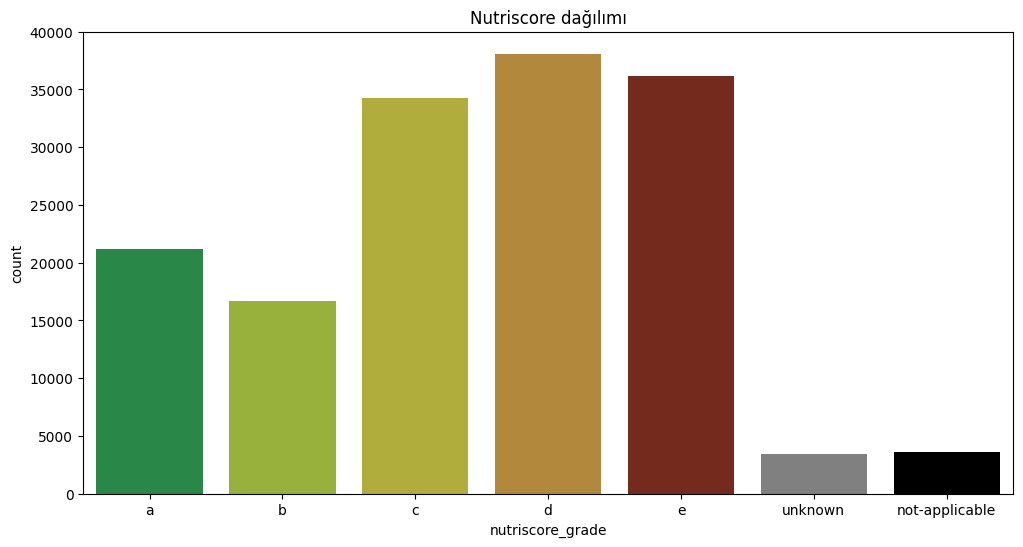

nutriscore_grade
d                 25%
e                 24%
c                 22%
a                 14%
b                 11%
not-applicable     2%
unknown            2%
Name: proportion, dtype: object
nutriscore_grade
d                 38108
e                 36157
c                 34289
a                 21172
b                 16646
not-applicable     3620
unknown            3386
Name: count, dtype: int64


In [125]:
plt.figure(figsize=(12, 6))
sns.countplot(x='nutriscore_grade',data=df_clean,palette=['#1a9641','#a3c429','#c4bf29','#c48e29','#822110','gray','black'],order=['a','b','c','d','e','unknown','not-applicable'])
plt.title('Nutriscore dağılımı')
plt.show()
print((df_clean['nutriscore_grade'].value_counts(normalize=True).map("{:.0%}".format)))
print((df_clean['nutriscore_grade'].value_counts(normalize=False)))

## Nutriscore Dağılımı
Nutriscore ürünlerin 100 gramındaki besin içeriklerinin puanlanmasıyla ortaya çıkar.

    FinalScore = Toplan Negatif Puanlar(N) - Toplam Pozitif Puanlar (P) şeklinde hesaplanır
    Negatif Puanlar
    - Enerji Yoğunluğu(kj)
    - Doymuş Yağlar(g)
    - Şekerler(g)
    - Sodyum(mg)
    Bu bileşenlerin yüksek olması gıdanın kalitesini düşürürken;
    Pozitif Puanlar
    - Doğal İçerik Oranı
    - Lif(g)
    - Protein(g)
    değerlerinin yüksek olması gıda kalitesini arttırır.
    Not: Eğer bir ürünün toplan negatif puanı belirli bir değerin üzerindeyse o ürünün içerisindeki protein puanı toplam skordan
    düşülmez. Bu kural aşırı şekerli veya yağlı gıdalara sadece protein ekleyerek kaliteli besin sınıfına girmesini engellemek
    için oluşturulmuştur.
- En kaliteli: a= Koyu yeşil 21179 veri
- Kaliteli: b= Açık yeşil 17491 veri
- Ne kaliteli Ne kalitesiz: c= Sarı 34405 veri
- Kalitesiz: d= Turuncu 38201 veri
- En kalitesiz: e= Kırmızı 36512 veri
- unknown: bilinmiyor 3670 veri
- not-applicable: sınıflandırma için uygun değil (vitaminler,gıda takviyeleri...) 3778 veri

Hesaplamayı daha iyi yapabilmek için unknown ve not-applicable veriler daha sonra silinecektir

/tmp/ipython-input-1617209077.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-1617209077.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




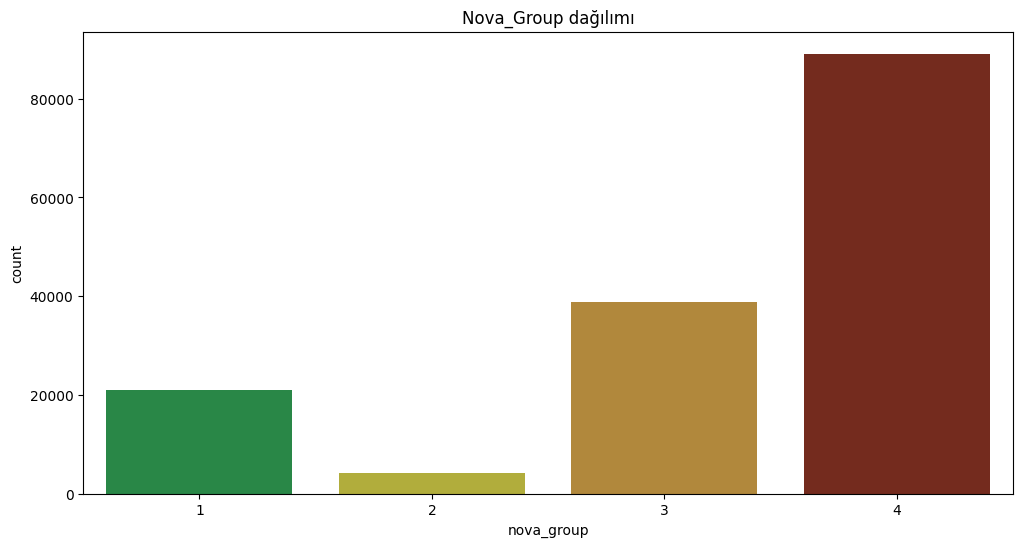

nova_group
4    58%
3    25%
1    14%
2     3%
Name: proportion, dtype: object


In [126]:
df_clean['nova_group'] = df_clean['nova_group'].astype(int)
plt.figure(figsize=(12, 6))
sns.countplot(x='nova_group',data=df_clean,palette=['#1a9641','#c4bf29','#c48e29','#822110'],order=["1",'2','3','4'])
plt.title('Nova_Group dağılımı')
plt.show()
print((df_clean['nova_group'].value_counts(normalize=True).map("{:.0%}".format)))

In [127]:
usuable_values = ['a','b','c','d','e']
df_clean = df_clean[df_clean['nutriscore_grade'].isin(usuable_values)]
nutri_mapping={
    'a':5,
    'b':4,
    'c':3,
    'd':2,
    'e':1
}
df_clean['nutriscore_encoded']=df_clean['nutriscore_grade'].map(nutri_mapping)
df_clean['environmental_score_score']=df_clean['environmental_score_score'].astype(float)
df_clean.head()

,code,brands,countries_tags,additives_n,nutriscore_grade,nova_group,environmental_score_score,main_category,energy-kj_100g,energy-kcal_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutriscore_encoded
13,15,Apple bandit,en:france,6.0,e,4,32.0,en:chocolate-madeleines,1926.0,460.0,24.0,6.0,31.00,1.4,6.4,0.48,0.192,1
48,51,Lindt,en:france,1.0,d,4,64.0,en:jams,1056.0,249.0,0.3,0.05,59.00,2.0,0.5,0.05,0.020,2
186,194,Biojoy,en:germany,0.0,b,1,33.0,en:walnut-kernels,2769.0,NaN,65.8,6.6,8.31,3.6,14.2,0.01,0.004,4
215,227,Bijou,en:france,8.0,e,4,31.0,en:filled-cakes,1807.0,NaN,20.0,5.0,37.00,1.0,5.3,0.70,0.280,1
219,231,Herbalife Nutrition,en:australia,5.0,d,4,35.0,en:peanut-butters,3160.0,400.0,4.0,2.0,28.00,8.0,28.0,1.70,0.680,2


In [128]:
countries_fq = df_clean['countries_tags'].value_counts().reset_index()
countries_fq.columns = ['country', 'frequency']

top_countries = countries_fq.head(15)
top_countries

,country,frequency
0,en:france,62054
1,en:germany,17395
2,en:spain,7363
3,en:italy,4917
4,en:united-kingdom,3920
5,"en:france,en:world",3409
6,en:poland,2753
7,"en:belgium,en:france",2106
8,en:netherlands,1983
9,"en:france,en:switzerland",1977


In [129]:
categories_fq = df_clean['main_category'].value_counts().reset_index()
categories_fq.columns = ['kategori', 'frekans']

top_categories = categories_fq.head(60)
top_categories

,kategori,frekans
0,en:groceries,3901
1,en:biscuits,2156
2,en:candies,1487
3,en:yogurts,1309
4,en:crackers-appetizers,1091
5,en:sweetened-beverages,1078
6,en:cheeses,1017
7,en:dark-chocolates,958
8,en:potato-crisps-in-sunflower-oil,757
9,en:white-hams,716


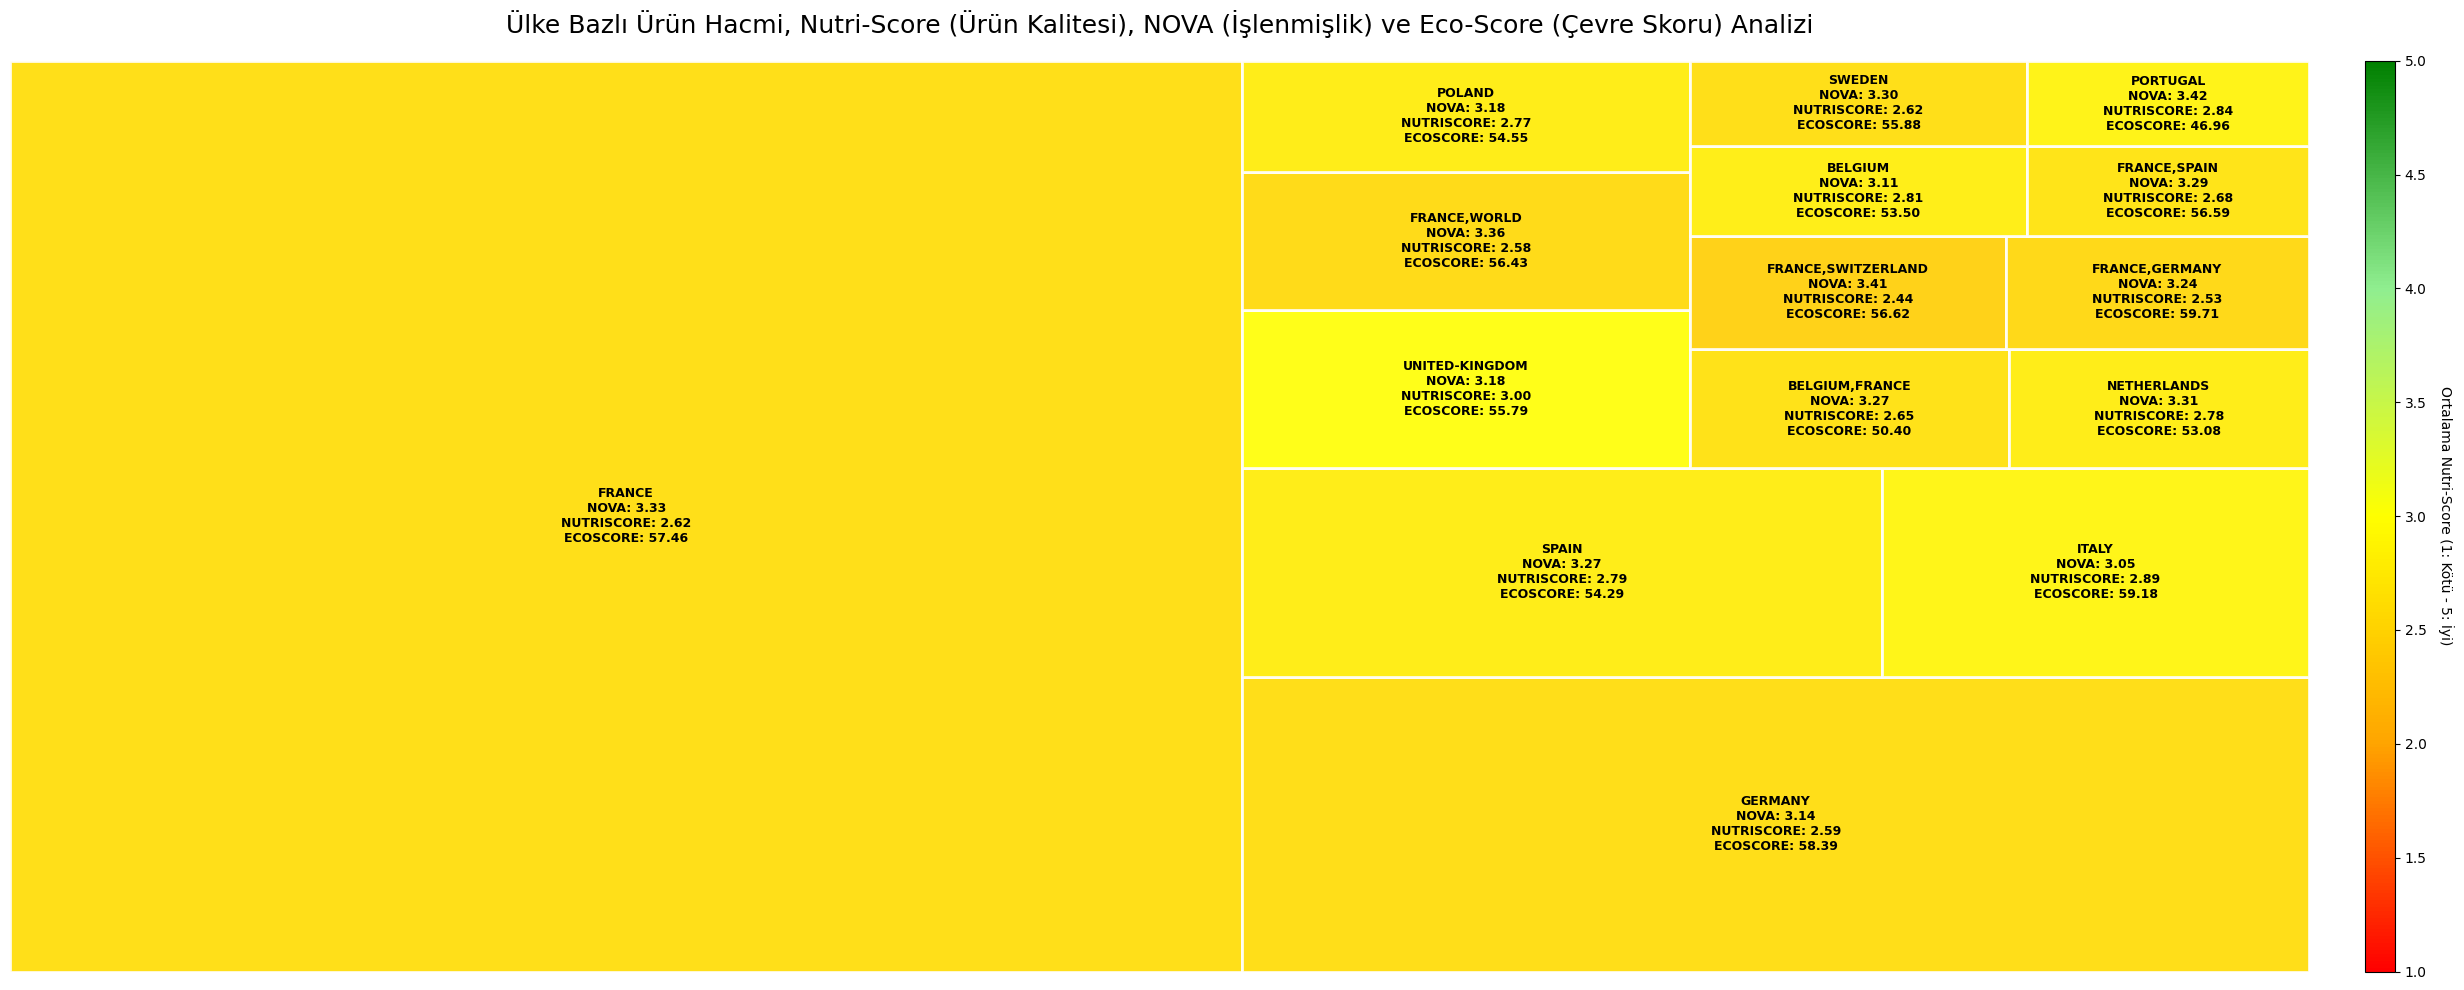

In [130]:
!pip install squarify
import squarify

country_avg_scores = df_clean.groupby('countries_tags').agg(
    Avg_Nutriscore=('nutriscore_encoded', 'mean'),
    Avg_Nova=('nova_group', 'mean'),
    Avg_Eco_Score=('environmental_score_score','mean')
).reset_index()
country_avg_scores.columns = ['country', 'ns_score', 'nova_score','environment_score']

plot_df = top_countries.merge(country_avg_scores, on='country', how='left')
plot_df = plot_df.rename(columns={'frequency': 'frekans'}) # Rename for consistency with original plot code
plot_df = plot_df.dropna(subset=['ns_score', 'nova_score', 'environment_score'])
cmap = mpl.colors.LinearSegmentedColormap.from_list("",['red','orange','yellow','lightgreen','green'])
norm = mpl.colors.Normalize(vmin=1,vmax=5)
colors = [cmap(norm(value)) for value in plot_df['ns_score']]
labels = [f"{u.upper().replace('EN:','')}\nNOVA: {nv:.2f}\nNUTRISCORE: {ns:.2f}\nECOSCORE: {es:.2f}" for u, nv, ns, es in zip(plot_df['country'], plot_df['nova_score'],plot_df['ns_score'],plot_df['environment_score'])]
plt.figure(figsize=(28, 10), facecolor='white')

squarify.plot(
    sizes=plot_df['frekans'],
    label=labels,
    color=colors,
    alpha=0.9,
    edgecolor="white",
    linewidth=2,
    text_kwargs={'fontsize': 9, 'weight': 'bold', 'color': 'black'}
)

plt.title("Ülke Bazlı Ürün Hacmi, Nutri-Score (Ürün Kalitesi), NOVA (İşlenmişlik) ve Eco-Score (Çevre Skoru) Analizi", fontsize=18, pad=20)
plt.axis('off')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, aspect=30, pad=0.02, ax=plt.gca())
cbar.set_label('Ortalama Nutri-Score (1: Kötü - 5: İyi)', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

### KUTU GRAFİĞİ ANALİZİ
- Kutuların boyutu o ülkede satılan ürün miktarı ne kadar fazlaysa o kadar büyük
- Kutuların renngini o ülkede satılan ürünlerin nutriscore(=100 gramındaki besin içeriği işlenmişliğe önem vermez) değerlerinin ortalaması alınarak hesaplandı ve renkler buna göre belirlendi
  - Yeşil: Ürünlerin besin içeriği zengin
  - Açık Yeşil: Ürünlerin besin içeriği iyi
  - Sarı: Ürünlerin besin içeriği fena değil
  - Turuncu: Ürünlerin besin içeriği kötü
  - Kırmızı: Ürünlerin besin içeriği kalitesiz
- Kutuların içerisinde yer alan NOVA değeri ülkedeki satılan ürünlerin işlenmişlik derecesinin ortalaması alınarak hesaplandı
  - Nova= 1: Ürünler işlenmemiş veya az işlenmiş (Meyve, Sebze, taze et...)
  - Nova= 2: Ürünler işlenmiş (Tuz, Şeker, Sıvı Yağ...)
  - Nova= 3: Ürünler iyi işlenmiş (Konserveler, Paketli Ekmekler, Peynirler)
  - Nova= 4: Ürünler aşırı işlenmiş (Dondurulmuş gıdalar, Paketli abur cuburlar)
- Kutuların içerisinde yer alan ECOSCORE değeri ülkede tüketilen ürünlerin üretiminden- tüketimine kadar olan süreçte oluşturduğu ekolojik iz anlamına gelmektedir. environmental_score_score değerinin ülke bazlı ortalaması alınarak hesaplandı. Değerin yükselmesi ekolojik izin düşmesi anlamına gelmektedir.

### ÜLKELERE GÖRE ÇIKARILABİLECEK SONUÇLAR
Bazı veriler Belçika,Fransa gibi iki ülkede de ortak satılan ürünleri gösterdiği için sonuçlar kısmında yer vermedim.
- Fransa en büyük alana sahip. Satılan gıda ürünleri diğer ülkelere göre daha fazla ürünlerin içerik bakımından kalitesi ortalamayken (Nutri-Score: 2.62), ürünler normalden daha fazla işlem görmüş (NOVA: 3.33) öte yandan ürünlerin ekolojik izi diğer ülkelere kıyasla biraz daha iyi olsada çevreye bıraktığı etki ortalama (57.46).

- Ürün çeşitliliği açısından ikinci sırada Almanya var. Almanya da satılan ürünlerin kaliteside veri setindeki diğer ürünler gibi ortalama (Nutri-Score: 2.59). Ürünlerin işlenmişlik deresi normalin üstündeyken (NOVA: 3.14) çevreye bıraktığı etki ortalama düzeyde (58.39).

- İspanya: Ürün hacmi bakımından üçüncü sırada yer alıyor. Besin kalitesi (Nutri-Score: 2.79) genel ortalamada seyrediyor. Ürünlerin işlenmişlik düzeyi (NOVA: 3.27) ise paketli gıdaların ağırlıkta olduğunu gösteriyor. Ekolojik iz performansı (54.29) diğer büyük hacimli ülkelere benzer şekilde orta düzeyde.

- İtalya: Dikkat çekici bir veri sunuyor; büyük hacimli ülkeler arasında en düşük işlenmişlik oranına (NOVA: 3.05) ve en iyi ekolojik skora (59.18) sahip. Bu durum, İtalya'da satılan ürünlerin diğerlerine göre daha az aşırı işlem görmüş ve çevreye daha az yük bindiren ürünler olduğunu kanıtlıyor.

- Birleşik Krallık (UK): Ürün hacmi orta-yüksek seviyede. Nutri-Score (3.00) neredeyse 3 sınırında, yani besin değeri diğer ülkelere göre bir tık daha dengeli görünüyor. İşlenmişlik ve çevre skorları ise Avrupa ortalamasına paralel bir çizgide.

- Polonya: Besin içeriği kalitesi (2.78) açısından listenin biraz daha gerisinde kalsa da, çevre hassasiyeti (53.08) ve orta karar işlenmişlik düzeyiyle dengeli bir profil çiziyor.

- Hollanda: Ürün hacmi nispeten düşük olsa da ürünlerin işlenmişlik oranı (NOVA: 3.31) oldukça yüksek. Besin kalitesi (2.78) ise ortalamanın hafif altında kalarak endüstriyel gıda ağırlıklı bir pazara işaret ediyor.

- Belçika 2.81 Nutri-Score 3.11 işlenmişlik derecesine sahip ürünler ne kadar işlenmiş olsada besin içeriği açısından o kadar zengin değildir. 53.50 eco score ile ekolojik alnamada ortalama sınıftadır.

- İsveç: Hacim olarak küçük bir kutu kaplasa da, veri setindeki en düşük Nutri-Score (2.62) değerlerinden birine sahip. Yani satılan ürünlerin besin içeriği zenginliği açısından zayıf olduğu söylenebilir. Ancak ekolojik izi (55.88) çevre açısından başarılı bir not alıyor.

- Portekiz: Tablonun en uç verilerinden birine sahip. Küçük bir hacme sahip olmasına rağmen, en yüksek işlenmişlik derecesi (NOVA: 3.42) ve en düşük Eco-Score (46.96) Portekiz'de. Bu, Portekiz pazarındaki ürünlerin hem çok fazla işlem gördüğünü hem de çevreye en fazla zarar veren üretim süreçlerinden geçtiğini gösteriyor.


In [132]:
import plotly.graph_objects as go

categories_avg_score = df_clean.groupby('main_category').agg(
     Avg_Nutriscore=('nutriscore_encoded', 'mean'),
     Avg_Nova=('nova_group', 'mean'),
     Avg_Eco_Score=('environmental_score_score','mean')
 ).reset_index()
categories_avg_score.columns = ['kategori', 'ns_score', 'nova_score','environment_score']

category_df = top_categories.merge(categories_avg_score, on='kategori', how='left')
category_df = category_df.dropna(subset=['ns_score', 'nova_score', 'environment_score'])
category_df['size_calc'] = np.sqrt(category_df['frekans'])
sizeref = 3. * max(category_df['size_calc']) / (80**2)
display_name = []
fig = go.Figure()

for i, (index, row) in enumerate(category_df.iterrows()):
    display_name = row['kategori'].upper().replace('EN:', '')
    product_number = int(row['frekans'])

    fig.add_trace(go.Scatter(
        x=[row['nova_score']],
        y=[row['environment_score']],
        name=display_name,
        mode='markers',
        marker=dict(
            size=[row['size_calc']],
            sizemode='area',
            sizeref=sizeref,
            line_width=1.5,
            color=[row['ns_score']],
            colorscale='RdYlGn',
            cmin=1,
            cmax=5,
            showscale=True if i == 0 else False,
            colorbar=dict(
                title="Ort. Nutri-Score",
                x=1.2,
                thickness=15
            )
        ),
        text=display_name,
        hovertemplate=(
            f"<b>{display_name}</b><br>" +
            f"Ürün Sayısı:{product_number}<br>"+
            "Nutri-Score: %{marker.color:.2f}<br>" +
            "NOVA (İşlenmişlik): %{x:.2f}<br>" +
            "Eco-Score (Ekolojik iz): %{y:.2f}<br>" +
            "<extra></extra>"
        )
    ))

fig.update_layout(
   title='Kategori Bazlı Ürün Analizi: NOVA, Eco-Score ve Nutri-Score Korelasyonu',
   title_x=0.5,
    xaxis=dict(
        title='Ortalama İşlenmişlik Derecesi (NOVA: 1-4)',
        gridcolor='white',
        range=[0.5, 4.5],
        dtick=1
    ),
    yaxis=dict(
        title='Ortalama Çevre Skoru (Eco-Score: 0-100)',
        gridcolor='white',
        range=[-5, 105]
    ),
    paper_bgcolor='rgb(243, 243, 243)',
    plot_bgcolor='rgb(243, 243, 243)',
    legend=dict(
        x=1,
        y=1,
        xanchor='left',
        orientation='v'
    ),
    margin=dict(r=150)
)
fig.show()

In [133]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

df_clean['fiber_100g'] = df_clean['fiber_100g'].fillna(0)
frequency_map = df_clean['main_category'].value_counts().to_dict()
df_clean['main_category_freq'] = df_clean['main_category'].map(frequency_map)
df_clean['main_category_freq'] = df_clean['main_category_freq'] / len(df_clean)

In [134]:
features = [
    'fat_100g', 'saturated-fat_100g', 'sugars_100g',
    'proteins_100g', 'salt_100g', 'energy-kj_100g',
    'additives_n', 'main_category_freq', 'fiber_100g'
]
x=df_clean[features]
y=df_clean['nutriscore_encoded']

In [135]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

Model Doğruluğu (Accuracy): %90.92

Sınıflandırma Raporu:

              precision    recall  f1-score   support

           e       0.95      0.95      0.95      7235
           d       0.93      0.93      0.93      7585
           c       0.88      0.91      0.89      6869
           b       0.84      0.78      0.81      3299
           a       0.89      0.91      0.90      4287

    accuracy                           0.91     29275
   macro avg       0.90      0.90      0.90     29275
weighted avg       0.91      0.91      0.91     29275



<Figure size 1200x1200 with 0 Axes>

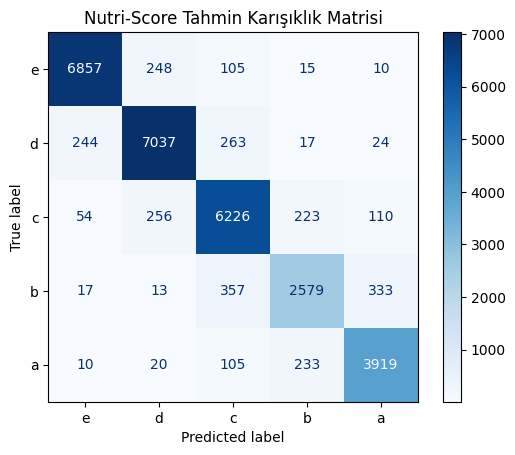

In [136]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf_model.predict(X_test)
print(f"Model Doğruluğu (Accuracy): %{accuracy_score(y_test, y_pred) * 100:.2f}")
print("\nSınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred, target_names=['e', 'd', 'c', 'b', 'a']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['e', 'd', 'c', 'b', 'a'])
plt.figure(figsize=(12, 12))
disp.plot(cmap='Blues', values_format='d')
plt.title('Nutri-Score Tahmin Karışıklık Matrisi')
plt.show()


##Confusion Matrix Açıklaması
- Besin Değeri En Düşük E Sınıfı
  - Toplam Ürün Sayısı: 7.235
  - Doğru Tahmin Sayısı: 6.857
  - Doğru Tahmin Oranı: %94.8
- Besin Değeri Düşük D Sınıfı
  - Toplam Ürün Sayısı: 7.585
  - Doğru Tahmin Sayısı: 7.037
  - Doğru Tahmin Oranı: %92.8
- Besin Değeri Ortalama C Sınıfı
  - Toplam Ürün Sayısı: 6.869
  - Doğru Tahmin Sayısı: 6.226
  - Doğru Tahmin Oranı: %90.6
- Besin Değeri İyi B Sınıfı
  - Toplam Ürün Sayısı: 2.299
  - Doğru Tahmin Sayısı: 2.579
  - Doğru Tahmin Oranı: %78.1
- Besin Değeri En İyi A Sınıfı
  - Toplam Ürün Sayısı: 4.287
  - Doğru Tahmin Sayısı: 3.919
  - Doğru Tahmin Oranı: %91.4

/tmp/ipython-input-2824584574.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




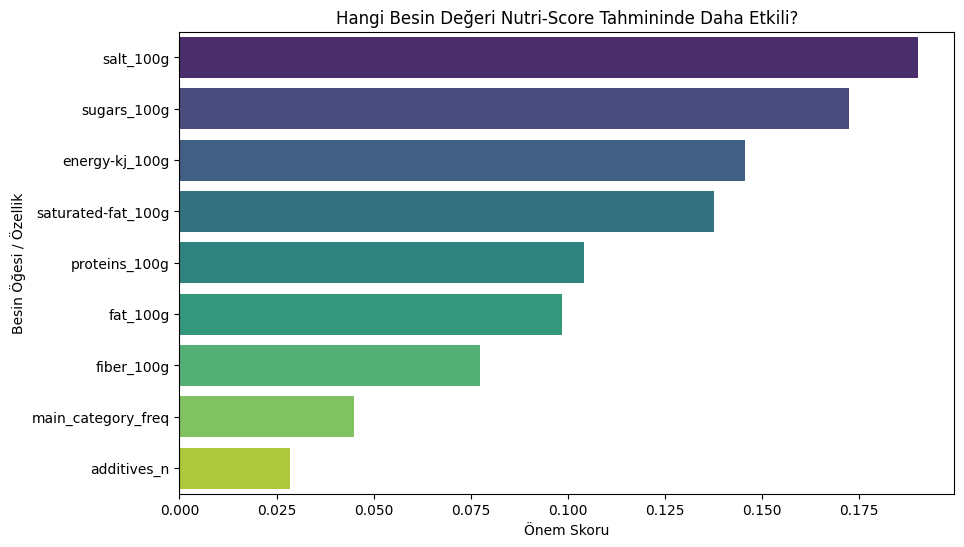

In [137]:
importances = rf_model.feature_importances_
feature_names = features
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Hangi Besin Değeri Nutri-Score Tahmininde Daha Etkili?')
plt.xlabel('Önem Skoru')
plt.ylabel('Besin Öğesi / Özellik')
plt.show()

In [138]:
X_nova = df_clean[features]
y_nova = df_clean['nova_group']
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_nova, y_nova, test_size=0.20, random_state=42)

rf_nova = RandomForestClassifier(n_estimators=100, random_state=42)
rf_nova.fit(X_train_n, y_train_n)

RandomForestClassifier(random_state=42)

NOVA Tahmin Doğruluğu: %88.86

NOVA Sınıflandırma Raporu:

              precision    recall  f1-score   support

           1       0.88      0.90      0.89      3985
           2       0.94      0.96      0.95       731
           3       0.81      0.80      0.80      7432
           4       0.92      0.92      0.92     17127

    accuracy                           0.89     29275
   macro avg       0.89      0.89      0.89     29275
weighted avg       0.89      0.89      0.89     29275



<Figure size 1200x1200 with 0 Axes>

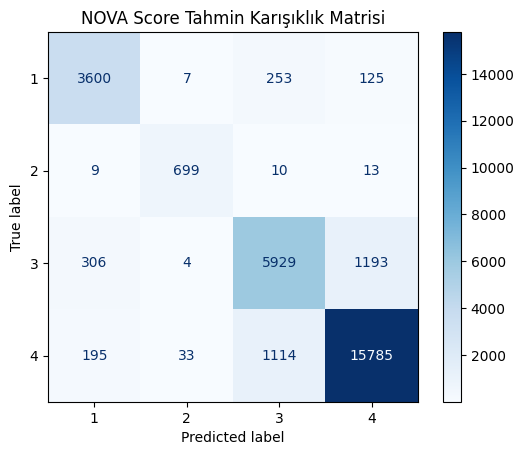

In [139]:
y_pred_nova = rf_nova.predict(X_test_n)
print(f"NOVA Tahmin Doğruluğu: %{accuracy_score(y_test_n, y_pred_nova) * 100:.2f}")
print("\nNOVA Sınıflandırma Raporu:\n")
print(classification_report(y_test_n, y_pred_nova))
cm = confusion_matrix(y_test_n, y_pred_nova)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['1', '2', '3', '4'])
plt.figure(figsize=(12, 12))
disp.plot(cmap='Blues', values_format='d')
plt.title('NOVA Score Tahmin Karışıklık Matrisi')
plt.show()

##Confusion Matrix Açıklaması
- İşlenmemiş/ Az İşlenmiş 1. Grup
  - Toplam Ürün Sayısı: 3.985
  - Doğru Tahmin Sayısı: 3.600
  - Doğru Tahmin Oranı: %89
- İşlenmiş 2. Grup
  - Toplam Ürün Sayısı: 731
  - Doğru Tahmin Sayısı: 699
  - Doğru Tahmin Oranı: %95
- Çok İşlenmiş 3. Grup
  - Toplam Ürün Sayısı: 7.432
  - Doğru Tahmin Sayısı: 5.929
  - Doğru Tahmin Oranı: %80
- Az İşlenmiş 4. Grup
  - Toplam Ürün Sayısı: 17.127
  - Doğru Tahmin Sayısı: 15.785
  - Doğru Tahmin Oranı: %92